# Burgers' Equation — Physics-Informed Neural Network (PINN)

This notebook trains a **PyTorch PINN** to approximate the solution of the 1-D
viscous Burgers equation

$$\frac{\partial u}{\partial t} + u\,\frac{\partial u}{\partial x}
   = \nu\,\frac{\partial^2 u}{\partial x^2},
   \qquad x\in[0,1],\; t\in[0,T].$$

It consumes the **high-fidelity finite-element data** produced by the FEniCSx
solver in this repository (`python -m src.run_burger`), using the stable
`[x, t, u]` dataset contract at `output/numpy/burgers_dataset.npy`.

**The loss has four parts** (the mix is what makes this a *physics-informed*
network rather than plain regression):

| term | meaning |
|------|---------|
| `L_data` | MSE against the FEM ground-truth samples (anchors the network to the high-fidelity solution) |
| `L_pde`  | MSE of the PDE residual $r=u_t+u\,u_x-\nu\,u_{xx}$ at random collocation points, via autograd |
| `L_ic`   | initial condition $u(x,0)=\sin(2\pi x)$ |
| `L_bc`   | Dirichlet boundaries $u(0,t)=u(1,t)=0$ |

> **Run order:** first generate the data (`python -m src.run_burger` from the
> repo root), then run this notebook top-to-bottom. Launch Jupyter from the
> **repository root** so the relative `output/...` paths resolve.


In [1]:
import json, os, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)

EPOCHS_ADAM = int(os.environ.get("PINN_EPOCHS", 10000))   # Adam iterations
LBFGS_STEPS = int(os.environ.get("PINN_LBFGS", 1500))     # LBFGS polish (0 = skip)
N_DATA      = int(os.environ.get("PINN_NDATA", 8000))   
N_COLL      = int(os.environ.get("PINN_NCOLL", 12000))    
LR          = float(os.environ.get("PINN_LR", 1e-3))
print(f"EPOCHS_ADAM={EPOCHS_ADAM} LBFGS_STEPS={LBFGS_STEPS} "
      f"N_DATA={N_DATA} N_COLL={N_COLL} LR={LR}")


torch 2.12.1+cu130 | device: cpu
EPOCHS_ADAM=10000 LBFGS_STEPS=1500 N_DATA=8000 N_COLL=12000 LR=0.001


## 1. Load the FEniCSx configuration and dataset

`config.json` carries the exact physics used to generate the data — we read
`nu` (and the domain/time extents) from it so the PINN's PDE residual is
guaranteed consistent with the ground truth.

In [ ]:
OUTPUT_DIR = "output"
with open(os.path.join(OUTPUT_DIR, "config.json")) as fh:
    fem_cfg = json.load(fh)

NU   = float(fem_cfg["nu"])
XMIN = float(fem_cfg["xmin"]); XMAX = float(fem_cfg["xmax"])
TMIN = 0.0;                    TMAX = float(fem_cfg["T"])
print(f"nu={NU}  x in [{XMIN},{XMAX}]  t in [{TMIN},{TMAX}]  IC={fem_cfg['initial_condition']}")

# [x, t, u] contract produced by src.io.pinn_dataset
data = np.load(os.path.join(OUTPUT_DIR, "numpy", "burgers_dataset.npy"))
assert data.ndim == 2 and data.shape[1] == 3, f"unexpected dataset shape {data.shape}"
x_all = data[:, 0:1]; t_all = data[:, 1:2]; u_all = data[:, 2:3]
print("dataset:", data.shape, "| u range [%.3f, %.3f]" % (u_all.min(), u_all.max()))

# Full FEM grid (for evaluation / plots): x (nx,), t (nt,), u (nt, nx)
grid = np.load(os.path.join(OUTPUT_DIR, "numpy", f"{fem_cfg['experiment_name']}.npz"))
x_grid, t_grid, U_grid = grid["x"], grid["t"], grid["u"]
print("FEM grid:", U_grid.shape)


## 2. Normalization and training tensors

In [3]:
def norm_x(x): return 2.0 * (x - XMIN) / (XMAX - XMIN) - 1.0
def norm_t(t): return 2.0 * (t - TMIN) / (TMAX - TMIN) - 1.0
SX = 2.0 / (XMAX - XMIN)   # d/dx  = SX * d/dx_hat
ST = 2.0 / (TMAX - TMIN)   # d/dt  = ST * d/dt_hat

def to_t(a): return torch.tensor(a, dtype=torch.float32, device=DEVICE)

# --- supervised anchor points sampled from the FEM dataset ---
sub = np.random.choice(len(data), size=min(N_DATA, len(data)), replace=False)
xd = to_t(norm_x(x_all[sub])); td = to_t(norm_t(t_all[sub])); ud = to_t(u_all[sub])

# --- interior collocation points for the PDE residual (normalized cube) ---
def sample_collocation(n):
    xc = torch.rand(n, 1, device=DEVICE) * 2 - 1
    tc = torch.rand(n, 1, device=DEVICE) * 2 - 1
    return xc.requires_grad_(True), tc.requires_grad_(True)
xc, tc = sample_collocation(N_COLL)

# --- initial condition: u(x,0) = sin(2 pi x) ---
xi = torch.rand(1000, 1, device=DEVICE) * 2 - 1
x_phys_ic = (xi + 1) / 2 * (XMAX - XMIN) + XMIN
u_ic = torch.sin(2 * np.pi * x_phys_ic)
t_ic = torch.full_like(xi, norm_t(np.array([[TMIN]]))[0, 0])

# --- Dirichlet boundaries: u(0,t) = u(1,t) = 0 ---
tb = torch.rand(1000, 1, device=DEVICE) * 2 - 1
xb_lo = torch.full_like(tb, norm_x(np.array([[XMIN]]))[0, 0])
xb_hi = torch.full_like(tb, norm_x(np.array([[XMAX]]))[0, 0])
print("anchors:", xd.shape[0], "| collocation:", xc.shape[0])


anchors: 8000 | collocation: 12000


## 3. The network

A fully-connected MLP $u_\theta(\hat x, \hat t)$ with `tanh` activations —
smooth and infinitely differentiable, which the autograd-based PDE residual
requires.

In [5]:
class PINN(nn.Module):
    def __init__(self, layers=(2, 8, 8, 8, 8, 1)):
        super().__init__()
        seq = []
        for i in range(len(layers) - 1):
            seq.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                seq.append(nn.Tanh())
        self.net = nn.Sequential(*seq)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = PINN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print("trainable parameters:", n_params)


PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): Tanh()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): Tanh()
    (6): Linear(in_features=8, out_features=8, bias=True)
    (7): Tanh()
    (8): Linear(in_features=8, out_features=1, bias=True)
  )
)
trainable parameters: 249


## 4. PDE residual and the composite loss

The residual is evaluated with `torch.autograd.grad`, taking derivatives of the
network output w.r.t. its inputs and rescaling to physical coordinates.

In [6]:
def pde_residual(xc, tc):
    u = model(xc, tc)
    u_th = torch.autograd.grad(u, tc, torch.ones_like(u), create_graph=True)[0]
    u_xh = torch.autograd.grad(u, xc, torch.ones_like(u), create_graph=True)[0]
    u_xxh = torch.autograd.grad(u_xh, xc, torch.ones_like(u_xh), create_graph=True)[0]
    u_t = u_th * ST
    u_x = u_xh * SX
    u_xx = u_xxh * SX * SX
    return u_t + u * u_x - NU * u_xx           # Burgers residual (== 0 ideally)

mse = nn.MSELoss()
# Loss weights: IC/BC upweighted so the (few) constraint points are not drowned
# out by the many interior points.
W_DATA, W_PDE, W_IC, W_BC = 1.0, 1.0, 10.0, 10.0

def compute_losses():
    l_data = mse(model(xd, td), ud)
    l_pde = mse(pde_residual(xc, tc), torch.zeros(xc.shape[0], 1, device=DEVICE))
    l_ic = mse(model(xi, t_ic), u_ic)
    l_bc = mse(model(xb_lo, tb), torch.zeros_like(tb)) \
         + mse(model(xb_hi, tb), torch.zeros_like(tb))
    total = W_DATA * l_data + W_PDE * l_pde + W_IC * l_ic + W_BC * l_bc
    return total, (l_data, l_pde, l_ic, l_bc)


## 5. Train — Adam

Adam does the bulk of the optimization. We resample collocation points
periodically so the PDE constraint is enforced across the whole domain rather
than a fixed subset.

In [7]:
history = {"total": [], "data": [], "pde": [], "ic": [], "bc": []}
opt = torch.optim.Adam(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=max(1, EPOCHS_ADAM // 5), gamma=0.5)

t0 = time.time()
for ep in range(EPOCHS_ADAM):
    if ep % 500 == 0 and ep > 0:                 # resample collocation set
        xc, tc = sample_collocation(N_COLL)
    opt.zero_grad()
    total, (l_data, l_pde, l_ic, l_bc) = compute_losses()
    total.backward()
    opt.step()
    sched.step()
    if ep % 200 == 0 or ep == EPOCHS_ADAM - 1:
        history["total"].append(total.item()); history["data"].append(l_data.item())
        history["pde"].append(l_pde.item());   history["ic"].append(l_ic.item())
        history["bc"].append(l_bc.item())
    if ep % 1000 == 0 or ep == EPOCHS_ADAM - 1:
        print(f"[{ep:5d}] total={total.item():.3e}  data={l_data.item():.3e}  "
              f"pde={l_pde.item():.3e}  ic={l_ic.item():.3e}  bc={l_bc.item():.3e}")
print(f"Adam done in {time.time()-t0:.1f}s")


[    0] total=6.050e+00  data=2.342e-01  pde=6.270e-02  ic=5.589e-01  bc=1.636e-02
[ 1000] total=3.542e-01  data=1.412e-02  pde=2.270e-01  ic=8.804e-03  bc=2.502e-03
[ 2000] total=3.148e-02  data=4.154e-04  pde=2.590e-02  ic=3.718e-04  bc=1.447e-04
[ 3000] total=1.567e-02  data=9.819e-05  pde=1.367e-02  ic=1.311e-04  bc=5.841e-05
[ 4000] total=9.191e-03  data=4.871e-05  pde=8.035e-03  ic=7.314e-05  bc=3.755e-05
[ 5000] total=6.754e-03  data=2.513e-05  pde=6.006e-03  ic=4.402e-05  bc=2.832e-05
[ 6000] total=4.480e-03  data=1.595e-05  pde=3.993e-03  ic=2.687e-05  bc=2.014e-05
[ 7000] total=3.875e-03  data=1.321e-05  pde=3.492e-03  ic=2.038e-05  bc=1.665e-05
[ 8000] total=2.890e-03  data=9.379e-06  pde=2.590e-03  ic=1.558e-05  bc=1.347e-05
[ 9000] total=2.516e-03  data=8.438e-06  pde=2.250e-03  ic=1.304e-05  bc=1.276e-05
[ 9999] total=2.017e-03  data=6.339e-06  pde=1.793e-03  ic=1.055e-05  bc=1.128e-05
Adam done in 267.4s


## 6. Refine — L-BFGS (optional)

A short L-BFGS phase (a full-batch quasi-Newton method) typically sharpens the
PINN considerably. Set `PINN_LBFGS=0` to skip it.

In [ ]:
if LBFGS_STEPS > 0:
    xc, tc = sample_collocation(N_COLL)
    opt_l = torch.optim.LBFGS(model.parameters(), max_iter=LBFGS_STEPS,
                              history_size=50, tolerance_grad=1e-9,
                              tolerance_change=1e-12, line_search_fn="strong_wolfe")
    _it = {"n": 0}
    def closure():
        opt_l.zero_grad()
        total, _ = compute_losses()
        total.backward()
        _it["n"] += 1
        if _it["n"] % 100 == 0:
            print(f"  LBFGS iter {_it['n']:4d}  loss={total.item():.3e}")
        return total
    t0 = time.time()
    opt_l.step(closure)
    final, parts = compute_losses()
    print(f"L-BFGS done in {time.time()-t0:.1f}s  final loss={final.item():.3e}")
else:
    print("L-BFGS skipped (PINN_LBFGS=0)")


## 7. Evaluate against the FEM ground truth

We predict on the full FEM space-time grid and report the relative $L^2$ error
$\lVert u_\theta - u_{\mathrm{FEM}}\rVert_2 / \lVert u_{\mathrm{FEM}}\rVert_2$.

In [8]:
TT, XX = np.meshgrid(t_grid, x_grid, indexing="ij")      # (nt, nx)
with torch.no_grad():
    xin = to_t(norm_x(XX.reshape(-1, 1)))
    tin = to_t(norm_t(TT.reshape(-1, 1)))
    U_pred = model(xin, tin).cpu().numpy().reshape(U_grid.shape)

rel_l2 = np.linalg.norm(U_pred - U_grid) / np.linalg.norm(U_grid)
max_err = np.abs(U_pred - U_grid).max()
print(f"relative L2 error vs FEM : {rel_l2:.3e}")
print(f"max abs error            : {max_err:.3e}")

# per-time relative error
per_t = np.linalg.norm(U_pred - U_grid, axis=1) / (np.linalg.norm(U_grid, axis=1) + 1e-12)
print(f"worst per-time rel error : {per_t.max():.3e} at t={t_grid[per_t.argmax()]:.3f}")


relative L2 error vs FEM : 5.529e-03
max abs error            : 1.219e-02
worst per-time rel error : 1.219e-02 at t=1.000


## 8. Visualize: PINN vs FEM

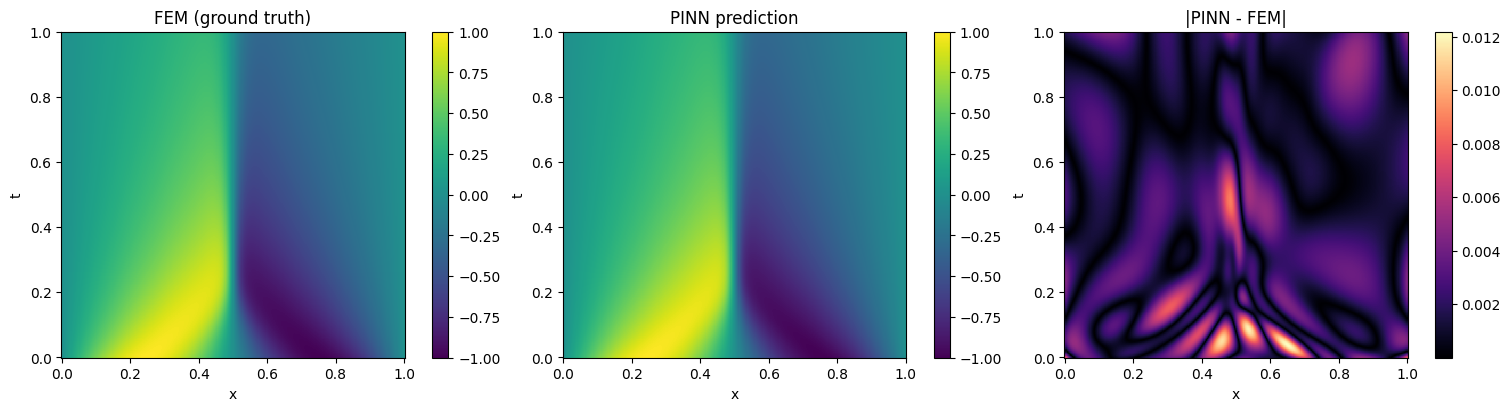

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
vmin, vmax = U_grid.min(), U_grid.max()
for ax, field, title in [(axes[0], U_grid, "FEM (ground truth)"),
                         (axes[1], U_pred, "PINN prediction")]:
    im = ax.pcolormesh(x_grid, t_grid, field, shading="auto", cmap="viridis",
                       vmin=vmin, vmax=vmax)
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(title)
    fig.colorbar(im, ax=ax)
im = axes[2].pcolormesh(x_grid, t_grid, np.abs(U_pred - U_grid), shading="auto",
                        cmap="magma")
axes[2].set_xlabel("x"); axes[2].set_ylabel("t"); axes[2].set_title("|PINN - FEM|")
fig.colorbar(im, ax=axes[2])
plt.show()


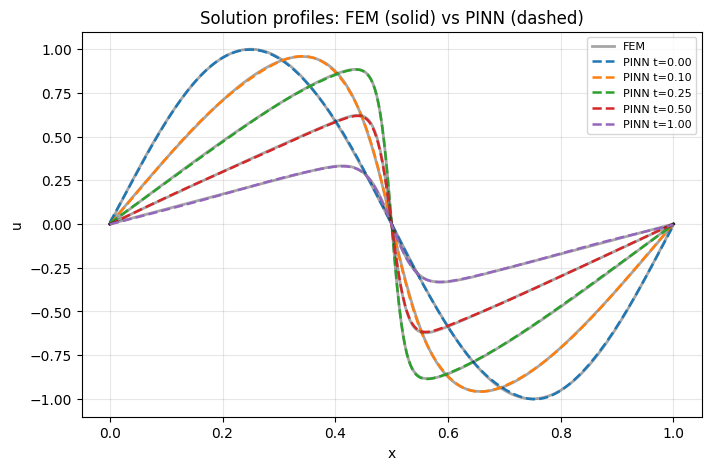

In [10]:
# solution profiles at several times
fig, ax = plt.subplots(figsize=(8, 5))
for frac in [0.0, 0.1, 0.25, 0.5, 1.0]:
    k = int(frac * (len(t_grid) - 1))
    ax.plot(x_grid, U_grid[k], color="k", lw=2, alpha=0.35,
            label="FEM" if frac == 0.0 else None)
    ax.plot(x_grid, U_pred[k], "--", lw=1.8,
            label=f"PINN t={t_grid[k]:.2f}")
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.set_title("Solution profiles: FEM (solid) vs PINN (dashed)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()


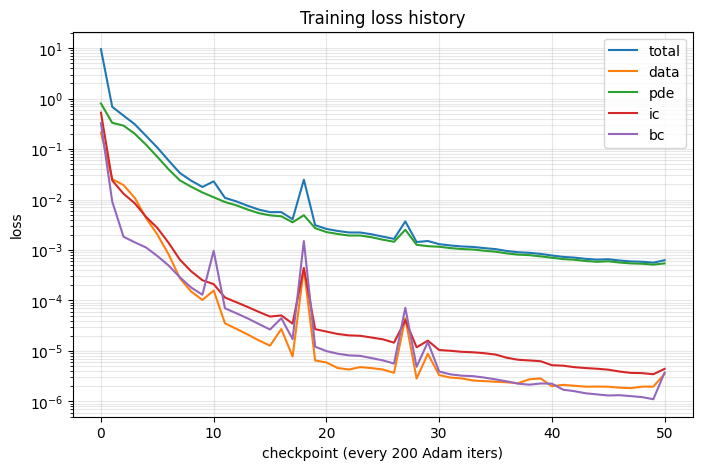

In [10]:
# loss history
fig, ax = plt.subplots(figsize=(8, 5))
for key in ["total", "data", "pde", "ic", "bc"]:
    ax.semilogy(history[key], label=key)
ax.set_xlabel("checkpoint (every 200 Adam iters)"); ax.set_ylabel("loss")
ax.set_title("Training loss history"); ax.legend(); ax.grid(alpha=0.3, which="both")
plt.show()


## 9. Save the trained model

In [11]:
os.makedirs("checkpoints", exist_ok=True)
ckpt_path = os.path.join("checkpoints", "burgers_pinn.pt")
torch.save({
    "state_dict": model.state_dict(),
    "arch": "MLP(2,64,64,64,64,1)-tanh",
    "nu": NU, "domain": [XMIN, XMAX], "T": TMAX,
    "normalization": {"norm_x": "2*(x-xmin)/(xmax-xmin)-1",
                      "norm_t": "2*t/T-1"},
    "rel_l2_vs_fem": float(rel_l2),
}, ckpt_path)
print("saved ->", ckpt_path, f"(rel L2 vs FEM = {rel_l2:.3e})")


saved -> checkpoints/burgers_pinn.pt (rel L2 vs FEM = 5.529e-03)


## Notes & next steps

- **Accuracy knobs.** Increase `PINN_EPOCHS`, enable/lengthen `PINN_LBFGS`, or
  widen the network for lower error. The data term keeps the PINN anchored to the
  FEM solution; the PDE term enforces the physics between samples.
- **Data-free / inverse variants.** Drop `W_DATA` to 0 to train a *pure* PINN
  (physics + IC/BC only) and compare against the FEM data as an unbiased test.
  To solve an **inverse problem**, make `NU` a `torch.nn.Parameter` and let the
  data term identify it.
- **Consistency.** `nu`, the domain, and `T` are read from `output/config.json`,
  so re-running `python -m src.run_burger` with a different physics config and
  re-running this notebook stays self-consistent.
